In [1]:
import jax
import jax.numpy as jnp
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

In [2]:
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 6.0
plt.rcParams['ytick.major.size'] = 6.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.minor.size'] = 4.0
plt.rcParams['ytick.minor.size'] = 4.0
plt.rcParams['xtick.minor.width'] = 0.8
plt.rcParams['ytick.minor.width'] = 0.8
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['font.size'] = 16
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['text.usetex'] = False

In [3]:
import ps_1loop_jax
import ps_1loop_jax.params as ps_params

In [4]:
model = ps_1loop_jax.PowerSpectrum1LoopLPT()

In [5]:
## input linear matter power spectrum as a dictionary
d = np.loadtxt('data/pk_lin_planck18_fid_z0.txt')
pk_data = jnp.stack([d[:,0], d[:,1]], axis=0)

## other model parameters
f = 0.578
bias = jnp.array([0.71, 0.26, 0.67, -0.2])
ctr = jnp.array([0.0, 0.0, 0.0, 0.0])
stoch = jnp.array([0.0, 0.0, 0.0])

params = ps_params.make_lpt_params(f=f, bias=bias, ctr=ctr, stoch=stoch)

In [7]:
## Output P(k,mu) as jax.numpy array of shape (len(k), len(mu))
k = jnp.linspace(1e-3, 0.3, 100)
mu = jnp.linspace(0.,1.,6)
%time pkmu = model.get_pkmu(k, mu, pk_data, params).block_until_ready()

CPU times: user 233 ms, sys: 77 ms, total: 310 ms
Wall time: 228 ms


## Redshift-space multiples ($\ell = 0, 2, 4$ are supported)

In [9]:
%time pkl = model.get_pk_ells(k, pk_data, params).block_until_ready()

CPU times: user 163 ms, sys: 67.1 ms, total: 230 ms
Wall time: 164 ms


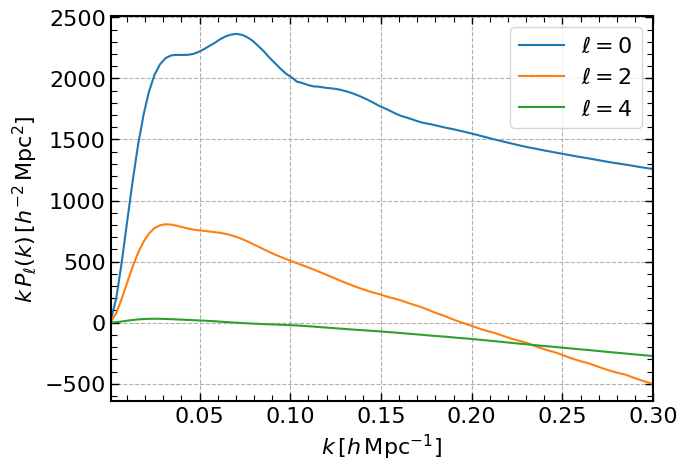

In [10]:
fig = plt.figure(figsize=(7,5))
color = plt.rcParams['axes.prop_cycle'].by_key()['color']
ax = fig.add_subplot()

for i, l in enumerate([0,2,4]):
    ax.plot(k, k * pkl[i], label=r'$\ell = %s$' % (l))

axs = plt.gcf().get_axes()
for ax in axs:
    plt.sca(ax)
    plt.xlabel(r'$k \, [h \, \mathrm{Mpc}^{-1}]$')
    plt.ylabel(r'$k \, P_{\ell}(k) \, [h^{-2} \, \mathrm{Mpc}^2]$')
    plt.xlim(k.min(), k.max())
    plt.legend(fontsize=16)
    plt.grid(linestyle='--')

## Alcock-Pacynski effect

In [12]:
# AP parameters, depending on the reference cosmology and redshift
alpha_perp = 1.01
alpha_para = 1.0

%time pkl_AP = model.get_pk_ells_ref(k, alpha_perp, alpha_para, pk_data, params).block_until_ready()

CPU times: user 158 ms, sys: 49.2 ms, total: 207 ms
Wall time: 152 ms


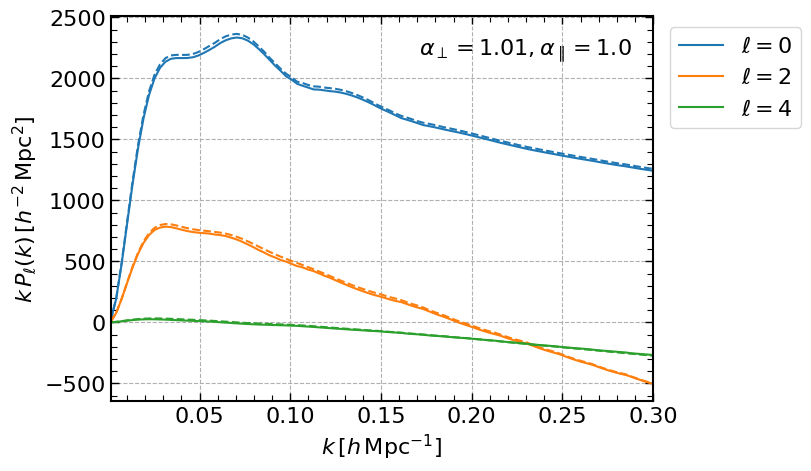

In [13]:
fig = plt.figure(figsize=(7,5))
color = plt.rcParams['axes.prop_cycle'].by_key()['color']
ax = fig.add_subplot()

for i, l in enumerate([0,2,4]):
    ax.plot(k, k * pkl_AP[i], c=color[i], label=r'$\ell = %s$' % (l))
    ax.plot(k, k * pkl[i], ls='--', c=color[i], )

ax.text(0.96, 0.9, r'$\alpha_\perp=%s, \alpha_\parallel=%s$' % (alpha_perp, alpha_para), fontsize=16, transform=ax.transAxes, ha='right')
    
axs = plt.gcf().get_axes()
for ax in axs:
    plt.sca(ax)
    plt.xlabel(r'$k \, [h \, \mathrm{Mpc}^{-1}]$')
    plt.ylabel(r'$k \, P_{\ell}(k) \, [h^{-2} \, \mathrm{Mpc}^2]$')
    plt.xlim(k.min(), k.max())
    plt.legend(fontsize=16, bbox_to_anchor=(1.01, 1.0), loc='upper left')
    plt.grid(linestyle='--')